In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [2]:
def quantile_list(key):
    quantiles = np.zeros(86)
    for j in range(86):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("mass_1_source")
quantiles_detector = quantile_list("mass_1")
quantiles_chirp = quantile_list('chirp_mass')
quantiles_mass_ratio = quantile_list('mass_ratio')

FileNotFoundError: [Errno 2] No such file or directory: 'gw_posteriors/source_85/posterior.npz'

Text(0.5, 0, 'chirp mass quantiles')

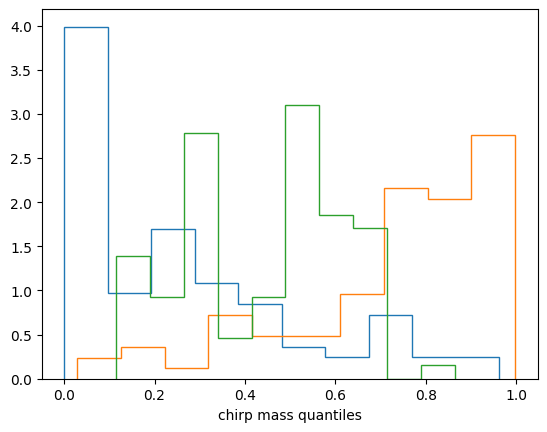

In [6]:

plt.hist(quantiles_chirp, histtype="step", density=True)
plt.hist(quantiles_mass_ratio, histtype="step", density=True)
plt.hist(quantile_list("chi_1"), histtype="step", density=True)
plt.xlabel("chirp mass quantiles")

In [3]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [5]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


# Add $\cos(\iota)$

In [14]:
posterior_mm = np.load("./gw_posteriors/source_0/posterior_mm.npz")

In [15]:
for key in posterior_mm.keys():
    print(key)

mass_ratio
chi_1
chi_2
lambda_1
lambda_2
psi
theta_jn
chirp_mass
geocent_time
phase
luminosity_distance
ra
dec
log_likelihood
log_prior
reference_frequency
waveform_approximant
minimum_frequency
total_mass
mass_1
mass_2
a_1
cos_tilt_1
a_2
cos_tilt_2
phi_jl
phi_12
tilt_1
tilt_2
symmetric_mass_ratio
iota
spin_1x
spin_1y
spin_1z
spin_2x
spin_2y
spin_2z
phi_1
phi_2
chi_eff
chi_1_in_plane
chi_2_in_plane
chi_p
redshift
comoving_distance
mass_1_source
mass_2_source
chirp_mass_source
total_mass_source
lambda_tilde
delta_lambda_tilde


In [95]:
quantiles_iota_gw = np.zeros(events.shape[0])
quantiles_dL_gw = np.zeros(events.shape[0])
quantiles_iota_em = np.zeros(events.shape[0])
quantiles_dL_em = np.zeros(events.shape[0])


for j in range(events.shape[0]):

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    gw_posterior["cos_theta_jn"] = np.cos(gw_posterior["theta_jn"])
    quantiles_iota_gw[j] = np.sum(gw_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / gw_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_gw[j] = np.sum(gw_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / gw_posterior["luminosity_distance"].shape[0] 
 
    
    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    em_posterior["cos_theta_jn"] = upside_downside * np.cos(em_posterior["inclination_EM"])
    quantiles_iota_em[j] = np.sum(em_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / em_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_em[j] = np.sum(em_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / em_posterior["luminosity_distance"].shape[0] 
 

In [110]:
np.argsort(quantiles_iota_em)

array([37, 66, 54, 13, 68, 26, 40, 48,  5, 50, 83, 23, 80, 24, 61, 58,  3,
        1, 65, 72, 84, 20, 53, 51, 82, 49, 10, 30, 15, 34, 43, 67, 32, 25,
       27, 12, 79, 44, 74, 45, 22, 29, 21, 11, 55, 69, 76, 28, 38, 81, 47,
       62, 14, 18, 33, 46, 31,  8, 71, 41,  7, 16, 36, 17, 52, 64, 70, 39,
       77, 59,  2, 78,  0,  6, 73, 60, 56, 19, 75,  9, 35, 42,  4, 57, 63])

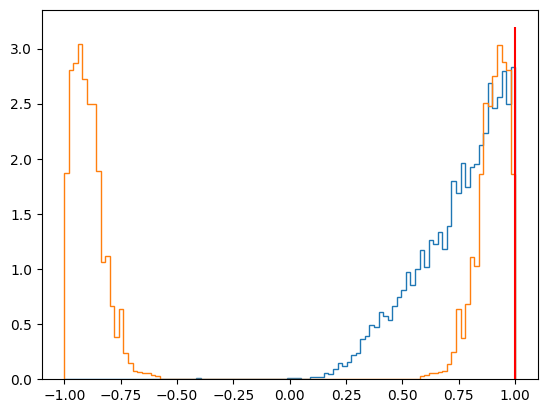

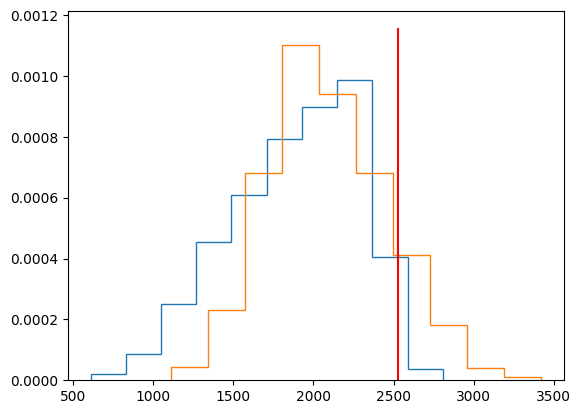

In [114]:
src = 57
for j in [src]:

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    gw_posterior["cos_theta_jn"] = np.cos(gw_posterior["theta_jn"])
    

    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    em_posterior["cos_theta_jn"] = upside_downside * np.cos(em_posterior["inclination_EM"])

plt.hist(gw_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.hist(em_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")
plt.show()

plt.hist(gw_posterior["luminosity_distance"], histtype="step", density=True)
plt.hist(em_posterior["luminosity_distance"], histtype="step", density=True)
plt.vlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_ylim(), color="red")
plt.show()

In [115]:
for j in range(events.shape[0]):

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    gw_posterior["cos_theta_jn"] = np.cos(gw_posterior["theta_jn"])
    np.savez(gw_file, **gw_posterior)
    
    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    em_posterior["cos_theta_jn"] = upside_downside * np.cos(em_posterior["inclination_EM"])
    np.savez(em_file, **em_posterior)
